In [121]:
import pandas as pd
import numpy as np

In [122]:
df = pd.read_excel(
    "Fisheries_CA2_Dataset.xlsx"
)

In [123]:
df.head()

,County,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Export_Demand_Level,Vessel_Type,Sustainability_Score,Predicted_Annual_Revenue_EUR
0,Waterford,81077.05,91.19,6.95,5.10,7.10,1.23,4.12,108112.88,High,Longliner,99.44,201495.28
1,Clare,76078.84,99.09,7.51,8.20,6.16,5.38,4.06,112746.74,Average,Trawler,115.02,202484.46
2,Cork,50576.94,91.93,7.59,3.82,4.04,4.71,3.07,132088.49,Low,Longliner,61.75,107997.00
3,Dublin,73236.59,109.53,6.29,7.02,7.60,5.99,5.56,109732.87,Average,Small Boat,115.48,188797.98
4,Dublin,69185.63,109.94,5.41,5.27,8.59,5.38,5.72,91268.62,Average,NaN,110.90,147138.23


In [124]:
# Dataset shape

df.shape

(2080, 13)

In [125]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   County                        2059 non-null   str    
 1   Avg_Fisher_Income_EUR         2059 non-null   float64
 2   Fuel_Cost_Index               2059 non-null   float64
 3   Port_Accessibility_Score      2059 non-null   float64
 4   Fish_Stock_Index              2059 non-null   float64
 5   Water_Quality_Score           2059 non-null   float64
 6   Weather_Risk_Index            2059 non-null   float64
 7   Illegal_Fishing_Rate_%        2059 non-null   float64
 8   Aquaculture_Investment_EUR    2059 non-null   float64
 9   Export_Demand_Level           2059 non-null   str    
 10  Vessel_Type                   2059 non-null   str    
 11  Sustainability_Score          2059 non-null   float64
 12  Predicted_Annual_Revenue_EUR  2059 non-null   float64
dtypes: float64(10)

In [126]:
# Descriptive statistic

df.describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000
mean,72511.124876,100.088698,5.969354,5.955352,7.006960,4.114594,4.914230,109863.973458,103.040413,174679.905537
std,11845.548793,14.895004,1.980090,1.943586,1.457452,1.896673,2.002769,22225.645739,22.356924,43489.897248
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64806.695000,90.280000,4.620000,4.640000,6.020000,2.695000,3.565000,95427.780000,88.230000,145903.220000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80310.940000,109.885000,7.340000,7.260000,8.000000,5.430000,6.305000,125296.360000,118.050000,204900.420000
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


In [127]:
# Missing values

df.isnull().sum()

County                          21
Avg_Fisher_Income_EUR           21
Fuel_Cost_Index                 21
Port_Accessibility_Score        21
Fish_Stock_Index                21
Water_Quality_Score             21
Weather_Risk_Index              21
Illegal_Fishing_Rate_%          21
Aquaculture_Investment_EUR      21
Export_Demand_Level             21
Vessel_Type                     21
Sustainability_Score            21
Predicted_Annual_Revenue_EUR    21
dtype: int64

In [128]:
# Duplicate value

df.duplicated().sum()

np.int64(0)

In [129]:
# Numerical column

num_cols = df.select_dtypes(
    include=np.number
).columns

num_cols

Index(['Avg_Fisher_Income_EUR', 'Fuel_Cost_Index', 'Port_Accessibility_Score',
       'Fish_Stock_Index', 'Water_Quality_Score', 'Weather_Risk_Index',
       'Illegal_Fishing_Rate_%', 'Aquaculture_Investment_EUR',
       'Sustainability_Score', 'Predicted_Annual_Revenue_EUR'],
      dtype='str')

In [130]:
# Categoric columns

cat_cols = df.select_dtypes(
    include="object"
).columns

cat_cols

C:\Users\peric\AppData\Local\Temp\ipykernel_468\3720563403.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(


Index(['County', 'Export_Demand_Level', 'Vessel_Type'], dtype='str')

In [131]:
# Handlle missing numerical nalues

for col in num_cols:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

In [132]:
# Handle miss categorical values

for col in cat_cols:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [133]:
# Remove duplicate value

df = df.drop_duplicates()

In [134]:
# Check miss value again

df.isnull().sum()

County                          0
Avg_Fisher_Income_EUR           0
Fuel_Cost_Index                 0
Port_Accessibility_Score        0
Fish_Stock_Index                0
Water_Quality_Score             0
Weather_Risk_Index              0
Illegal_Fishing_Rate_%          0
Aquaculture_Investment_EUR      0
Export_Demand_Level             0
Vessel_Type                     0
Sustainability_Score            0
Predicted_Annual_Revenue_EUR    0
dtype: int64

In [135]:
# Dataset shape affter clean

df.shape

(2080, 13)

In [136]:
# Revenue variable

revenue = df[
    "Predicted_Annual_Revenue_EUR"
]

In [137]:
revenue.mean()

np.float64(174694.79427884615)

In [138]:
revenue.median()

np.float64(176154.6)

In [139]:
revenue.mode()

0    176154.6
Name: Predicted_Annual_Revenue_EUR, dtype: float64

In [140]:
revenue.std()

np.float64(43269.94509493774)

In [141]:
revenue.var()

np.float64(1872288148.5189266)

In [142]:
# Probability of high export demand

(

    df[
        "Export_Demand_Level"
    ] == "High"

).mean()

np.float64(0.25384615384615383)

In [143]:
# Import visualization library

import matplotlib.pyplot as plt
import seaborn as sns

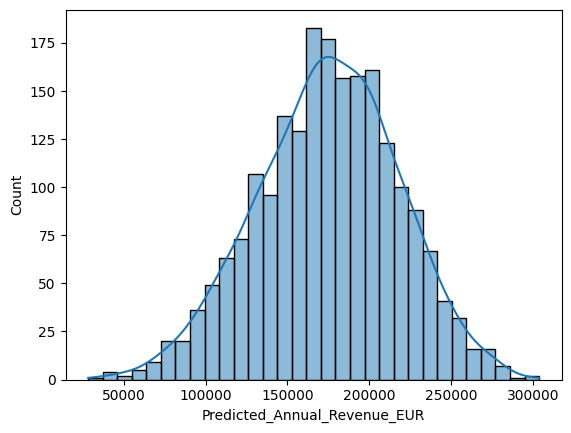

In [144]:
# Revenue distribution histogram

sns.histplot(
    revenue,
    kde=True
)

plt.show()

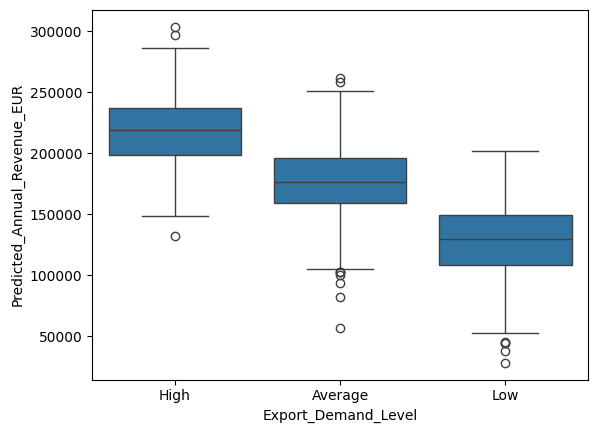

In [145]:
# Revenue by export demand level

sns.boxplot(

    x=df[
        "Export_Demand_Level"
    ],

    y=df[
        "Predicted_Annual_Revenue_EUR"
    ]

)

plt.show()